## **Título**: Ajuste fino a T5 para resúmenes de noticias deportivas

## **Alumno**: Josep Gabriel Fornes Reynes

# Introducción

Durante el desarrollo de la asignatura, hemos explorado el ajuste fino (*fine-tuning*) en distintas arquitecturas de Modelos de Lenguaje:
- **Arquitectura Encoder-only**: utilizamos el modelo **BERT** junto con el dataset *Yelp review* para tareas de **clasificación de texto** (análisis de sentimiento).
- **Arquitectura Decoder-only**: trabajamos con el modelo **Llama-2** aplicando la técnica **QLoRA** sobre el dataset *Guanaco* para la generación de texto conversacional.

Para complementar estas experiencias y cubrir el espectro completo de arquitecturas Transformer, este proyecto se centra en una arquitectura **Encoder-Decoder** (Seq2Seq). Esta arquitectura es ideal para tareas donde la entrada y la salida son secuencias de texto de longitud variable, como la traducción o el resumen.
El objetivo principal de este trabajo es realizar un resumen abstractivo de noticias en español. Para ello, se ha seleccionado el modelo **mT5-small** (Multilingual Text-to-Text Transfer Transformer), dado que es necesario procesar texto en castellano, y el dataset **MLSUM** (versión en español). Específicamente, se ha aplicado un filtrado temático al dataset para utilizar únicamente las noticias categorizadas como Deportes. Esta tarea presenta un desafío interesante de evaluación, ya que no se mide por exactitud (*accuracy*), sino mediante métricas de similitud de n-gramas como **ROUGE**, lo que permite analizar la capacidad del modelo para comprender y reescribir información compleja.

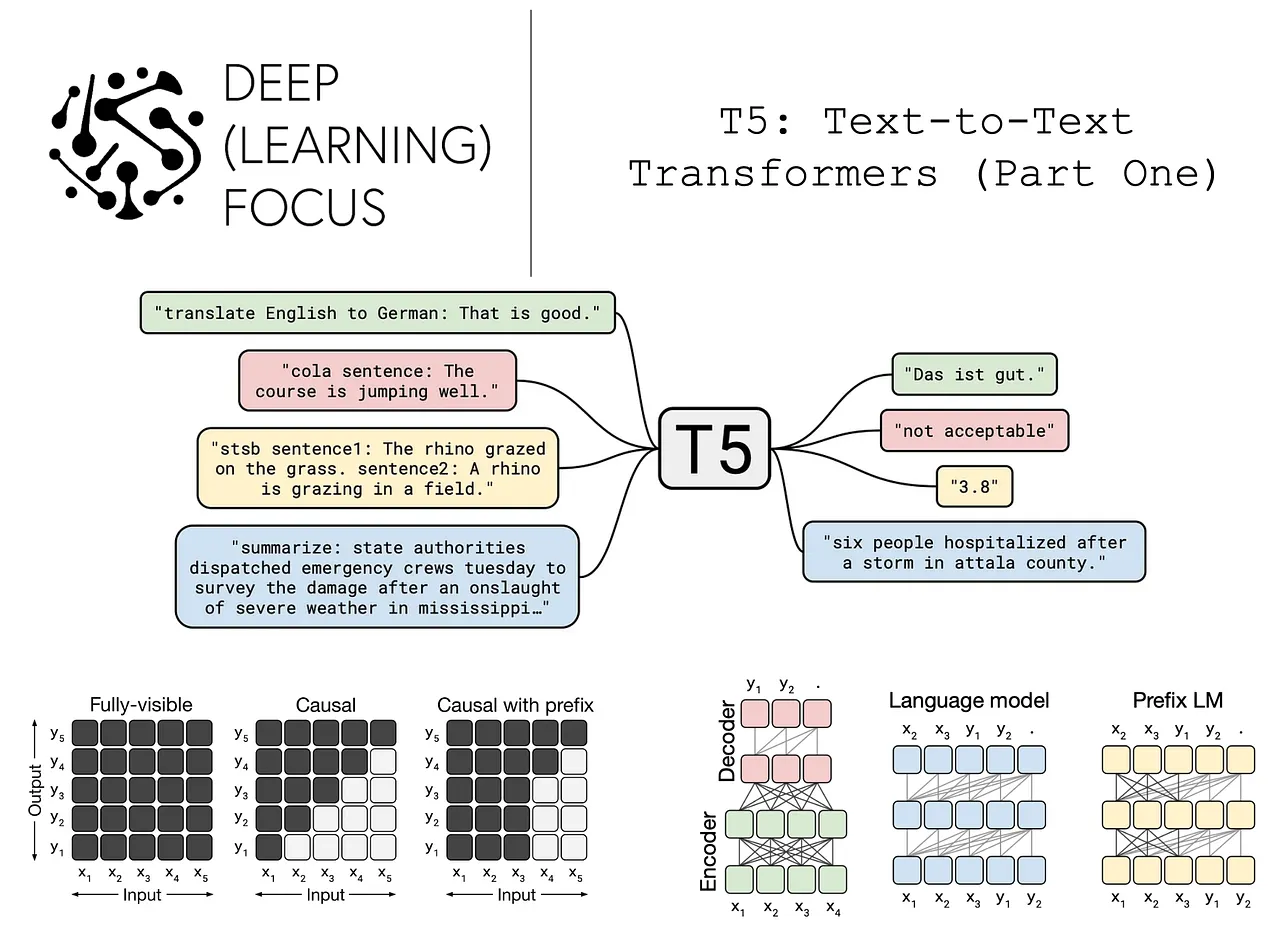

(Imagen obtenida desde [Deep (Learning) Focus](https://cameronrwolfe.substack.com/p/t5-text-to-text-transformers-part))

# Dataset

## Instalaciones necesarias

Para llevar a cabo el ajuste fino, utilizaremos el ecosistema de bibliotecas de **Hugging Face**, que se ha convertido en el estándar de la industria para NLP moderno. Las principales librerías son:
- `transformers`: el núcleo del proyecto. Nos proporciona la arquitectura del modelo T5 preentrenado y su tokenizador asociado.
- `accelerate`: optimiza el bucle de entrenamiento para que funcione de manera eficiente en la GPU T4 de Google Colab, gestionando el movimiento de tensores automáticamente.
- `evaluate`: la utilizaremos para cargar las métricas de evaluación del modelo.
- `rouge_score`: una dependencia específica necesaria para calcular la métrica ROUGE (Recall-Oriented Understudy for Gisting Evaluation), que es el estándar académico para evaluar la calidad de los resúmenes automáticos.
- `datasets`: fundamental para descargar y gestionar eficientemente el dataset MLSUM sin saturar la memoria RAM. Nota: Especificamos la versión `2.19.0` para garantizar la compatibilidad con los scripts de carga originales de este dataset (`trust_remote_code=True`), los cuales han sido restringidos en las versiones más recientes de la librería.

In [ ]:
!pip install -q transformers accelerate evaluate rouge_score

In [ ]:
!pip install -q datasets==2.19.0

In [ ]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer
from datasets import load_dataset
import evaluate
import numpy as np
import torch
import matplotlib.pyplot as plt

Miramos si tenemos la GPU operativa

In [ ]:
if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("No se ha detectado GPU.")

GPU detectada: Tesla T4


## Selección del dataset

Para el desarrollo de este proyecto, se ha utilizado el dataset **MLSUM** (*Multilingual Summarization*), específicamente su subconjunto en español. Este dataset es considerado el primer conjunto de datos a gran escala y de código abierto diseñado para la evaluación de resúmenes multilingües.

In [ ]:
# Cargar el dataset
dataset = load_dataset("reciTAL/mlsum", "es", trust_remote_code=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## Estructura de datos

Cada ejemplo del dataset contiene seis campos, siendo los tres primeros los más relevantes para nuestro entrenamiento:

- `text`: el cuerpo completo de la noticia. Esta será nuestra secuencia de entrada que el modelo deberá leer.

- `summary`:  el resumen de referencia generado por humanos. Esta será nuestra secuencia objetivo que el modelo intentará generar.

- `topic`: la categoría de la noticia. Este campo ha sido fundamental para realizar el filtrado temático previo.

- **Metadatos adicionales**: también disponemos de `title` (título), `url` (enlace original) y `date` (fecha), que proporcionan contexto adicional aunque no se utilizarán directamente como entrada para el modelo en esta configuración.

In [ ]:
# Ver la estructura de un ejemplo
print(dataset["train"][0].keys())

dict_keys(['text', 'summary', 'topic', 'url', 'title', 'date'])


## Preprocesamiento de datos

Para transformar los textos en secuencias numéricas comprensibles por el modelo, cargamos el tokenizador asociado al checkpoint `mt5-small` utilizando la clase `AutoTokenizer` de la librería Transformers.

In [ ]:
# Nombre del modelo
model_checkpoint = "google/mt5-small"

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Configuramos el tokenizador para utilizar el padding a la izquierda, modificando el comportamiento por defecto del modelo para adaptarlo mejor a la generación de secuencias en lotes.

In [ ]:
tokenizer.padding_side = "left"

Definimos la función para procesar los ejemplos del dataset, la cual implementa tres pasos críticos:
1. **Prefijo de tarea**: se añade la cadena `"summarize: "` al inicio de cada artículo. Esto es fundamental para **T5**, ya que al ser un modelo entrenado en múltiples tareas (traducción, corrección, etc.), necesita este *prompt* para activar su capacidad de resumen.

2. **Gestión de longitudes**:
- **Entradas (`text`)**: se establece una longitud máxima de 1024 tokens. Cualquier texto que exceda esta longitud se trunca, asegurando que la entrada quepa en la memoria de la GPU.

- **Salidas (`summary`)**: se establece una longitud máxima de 128 tokens para los resúmenes objetivo, ya que estos textos son naturalmente más breves.

In [ ]:
def tokenize_function(examples):
    # añadimos prefijo a las entradas
    inputs = ["summarize: " + doc for doc in examples["text"]]

    # tokenizamos la noticia
    model_inputs = tokenizer(inputs, max_length=1024, truncation=True)

    # tokenizar los resúmenes
    labels = tokenizer(text_target=examples["summary"], max_length=128, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

El dataset completo contiene casi 300.000 pares de noticias y resúmenes.

In [ ]:
print(f"Ejemplos del dataset: {len(dataset["train"]) + len(dataset["validation"]) + len(dataset["test"])}")

Ejemplos del dataset: 290645


Dado el gran volumen de datos de este dataset, y aprovechando la posibilidad de filtrar por la columna `topic`, hemos decidido seleccionar únicamente las noticias de deportes.

In [ ]:
# definimos el topic de deportes
target_topics = ["deportes"]

# función para filtrar
def filter_by_topic(example):
    topic = example['topic'].lower() if example['topic'] else ""
    return any(t in topic for t in target_topics)

# aplicamos filtro
sports_dataset = dataset.filter(filter_by_topic)

A pesar del filtrado, el dataset resultante sigue siendo extenso (más de 20.000 ejemplos). Entrenar con la totalidad de estos datos implicaría un coste computacional muy elevado y tiempos de ejecución prolongados.

In [ ]:
print(f"Ejemplos del dataset: {len(sports_dataset["train"]) + len(sports_dataset["validation"]) + len(sports_dataset["test"])}")

Ejemplos del dataset: 20239


Por los motivos mencionados, seleccionamos un subconjunto aleatorio y reproducible (utilizando una semilla `seed=42`) con las siguientes dimensiones:

- Conjunto de entrenamiento: **1.000 ejemplos**.
- Conjunto de validación: **200 ejemplos**.
- Conjunto de test: **200 ejemplos**.

In [ ]:
small_train_dataset = sports_dataset["train"].shuffle(seed=42).select(range(1000))
small_eval_dataset = sports_dataset["validation"].shuffle(seed=42).select(range(200))
small_test_dataset = sports_dataset["test"].shuffle(seed=42).select(range(200))

print(f"Entrenamiento: {len(small_train_dataset)}, Validación: {len(small_eval_dataset)}, Prueba: {len(small_test_dataset)}")

Entrenamiento: 1000, Validación: 200, Prueba: 200


Ejemplo de notícia de deporte:

In [ ]:
print(small_train_dataset[0])

{'text': 'Pau Gasol y Juan Carlos Navarro, 18 años después del triunfo bautismal ante Estados Unidos, son los únicos supervivientes de los júniors de oro en la selección española que afrontará el próximo Eurobasket. No se descarta el regreso de Felipe Reyes, que ha renunciado esta vez. En cambio, Navarro ya ha anunciado que se despedirá en la cita que concluye el 17 de septiembre en Estambul. El proceso de renovación ha sido y es constante en la selección sin perjuicio de unos resultados excelentes, a menudo óptimos desde 2001: 4 oros (un Mundial y tres Europeos) y 11 podios (incluidas dos platas en los Juegos Olímpicos). Y el potencial se mantiene e incluso se refuerza a pesar de las bajas de jugadores como Rudy Fernández, Claver, Pau Ribas, el nacionalizado de turno –Ibaka o Mirotic-, y Calderón, que puso punto final a su etapa internacional, de la misma forma que tiempo antes lo hizo Mumbrú y que en los últimos años se han retirado Raül López y Berni Rodríguez. Y la baja más inesper

Aplicamos la función declarada anteriormente a las tres particiones del dataset.

Gracias al parámetro `batched=True`, permitimos al tokenizador procesar lotes de ejemplos simultáneamente en lugar de iterar uno por uno, reduciendo drásticamente el tiempo de preparación de los datos

In [ ]:
# Aplicar la tokenización a las particiones el dataset
tokenized_train = small_train_dataset.map(tokenize_function, batched=True)
tokenized_val = small_eval_dataset.map(tokenize_function, batched=True)
tokenized_test = small_test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Realizamos una verificación y control de calidad:
1. **Inspección de estructura**: imprimimos las claves del primer elemento procesado para confirmar la existencia de los campos requeridos por el modelo como `input_ids` (la entrada codificada), `attention_mask` (máscara de atención) y `labels` (el objetivo codificado).

In [ ]:
print(tokenized_train[0].keys())
print(tokenized_val[0].keys())
print(tokenized_test[0].keys())

dict_keys(['text', 'summary', 'topic', 'url', 'title', 'date', 'input_ids', 'attention_mask', 'labels'])
dict_keys(['text', 'summary', 'topic', 'url', 'title', 'date', 'input_ids', 'attention_mask', 'labels'])
dict_keys(['text', 'summary', 'topic', 'url', 'title', 'date', 'input_ids', 'attention_mask', 'labels'])


2. **Inspección de contenido**: a continuación, visualizaremos muestras aleatorias de cada conjunto para corroborar visualmente que el texto ha sido correctamente transformado a tensores numéricos y que los prefijos de tarea se han añadido adecuadamente.

In [ ]:
print(tokenized_train[0])
print(tokenized_val[1])
print(tokenized_test[2])

# Implementación

Tras preparar los datos, se procede al ajuste fino del modelo. Este proceso se estructura en tres etapas clave implementadas en el código:
1. Inicialización del modelo y colacionador
2. Definición de la metrica
3. Configuración del entrenamiento

## 1. Inicialización del modelo y colacionador

Se carga el modelo preentrenado `AutoModelForSeq2SeqLM` con los pesos de `mT5-small`.

In [ ]:
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

Para gestionar los lotes de datos durante el entrenamiento, se instancia un `DataCollatorForSeq2Seq`. Este componente es crucial en tareas de generación, ya que se encarga de aplicar *padding* dinámico tanto a las secuencias de entrada como a las etiquetas, optimizando el uso de memoria de la GPU.

In [ ]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

## 2. Definición de la metrica

A diferencia de la clasificación, el resumen requiere métricas de similitud de texto. Se define la función `compute_metrics`, que decodifica las predicciones generadas por el modelo y las compara con los resúmenes de referencia utilizando la métrica **ROUGE**. Esta función también gestiona el post-procesamiento necesario para ignorar los tokens de relleno (*padding tokens*, representados por -100) en el cálculo de la métrica.

In [ ]:
rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.where(predictions != -100, predictions, tokenizer.pad_token_id)

    # Decodificar las predicciones
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)

    # Reemplazar -100 en las etiquetas porque el tokenizer no puede decodificarlos
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Calcular ROUGE
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

    prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id) for pred in predictions]
    result["gen_len"] = np.mean(prediction_lens)

    return {k: round(v, 4) for k, v in result.items()}

## 3. Configuración del entrenamiento

Se establecen los hiperparámetros que gobernarán el proceso de aprendizaje:
- `optim="adafactor"`: este optimizador fue diseñado específicamente para modelos T5. Gestiona la memoria de forma más eficiente y ofrece una mayor robustez contra inestabilidades durante el entrenamiento.
- `learning_rate=5e-4`: una tasa de aprendizaje conservadora para evitar el olvido catastrófico de los conocimientos previos del modelo.
- `per_device_train/eval_batch_size=4`: un tamaño de lote reducido para prevenir errores de memoria.
- `gradient_accumulation_steps=8`: para compensar el tamaño de lote pequeño, se acumulan los gradientes durante 8 pasos antes de actualizar los pesos. Esto resulta en un tamaño de lote efectivo de 32 (4 * 8), estabilizando el entrenamiento sin disparar el consumo de memoria.
- `warmup_steps=500`: se realizan 500 pasos de calentamiento inicial donde la tasa de aprendizaje aumenta gradualmente desde 0 hasta el valor objetivo (5e-4), lo que ayuda a estabilizar el inicio del entrenamiento.
- `weight_decay=0.01`: se aplica una técnica de regularización (L2) para penalizar los pesos excesivamente grandes durante la optimización
- `num_train_epochs=3`: se entrena durante 3 épocas completas para asegurar la convergencia.
- `save_total_limit=2`: se limita el almacenamiento a solo los 2 últimos checkpoints (o los mejores), borrando los antiguos para ahorrar espacio en disco.
- `predict_with_generate=True`: instrucción explícita para que el modelo genere texto completo durante la evaluación, permitiendo el cálculo de ROUGE.
- `fp16=False`: desactivación de precisión mixta para evitar desbordamientos numéricos.
- `eval_strategy="epoch"` y `save_strategy="epoch"`: la evaluación y el guardado de checkpoints se realizan al final de cada época.
- `load_best_model_at_end=True`: al finalizar el entrenamiento, se carga automáticamente el mejor modelo encontrado según la métrica de evaluación.

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir="modelo_resumen_mt5_v3",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    optim="adafactor",
    learning_rate=5e-4,
    warmup_steps=500,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=3,
    predict_with_generate=True,
    fp16=False,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="rouge1",
)

Se instancia el `Seq2SeqTrainer` con los componentes preparados anteriormente.

In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

/tmp/ipython-input-3690746773.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Ejecutamos el entrenamiento mediante el método `.train()`

In [ ]:
print("--- INICIANDO ENTRENAMIENTO ---")
trainer.train()
print("--- ENTRENAMIENTO FINALIZADO ---")

--- INICIANDO ENTRENAMIENTO ---


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,No log,3.269615,0.224400,0.052100,0.182300,0.182200,19.840000
2,No log,3.121503,0.228200,0.057100,0.183200,0.183200,19.875000
3,No log,3.021293,0.220100,0.056600,0.178300,0.178900,19.900000


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


--- ENTRENAMIENTO FINALIZADO ---


Guardamos el modelo final por si lo necesitamos posteriormente

In [ ]:
trainer.save_model("modelo_resumen_t5_final")

# Resultados y discusión

Una vez tenemos el modelo de generación de resúmenes entrenado, tenemos que realizar la evaluación de este modelo. Para realizar esta evaluación, vamos a extrae el historial de entrenamiento (`log_history`) para generar una gráfica dual.

Esta visualización permite monitorear simultáneamente la función de pérdida (Loss, eje derecho) y la calidad del resumen (ROUGE-1, eje izquierdo) a lo largo de las épocas, proporcionando evidencia empírica del aprendizaje.

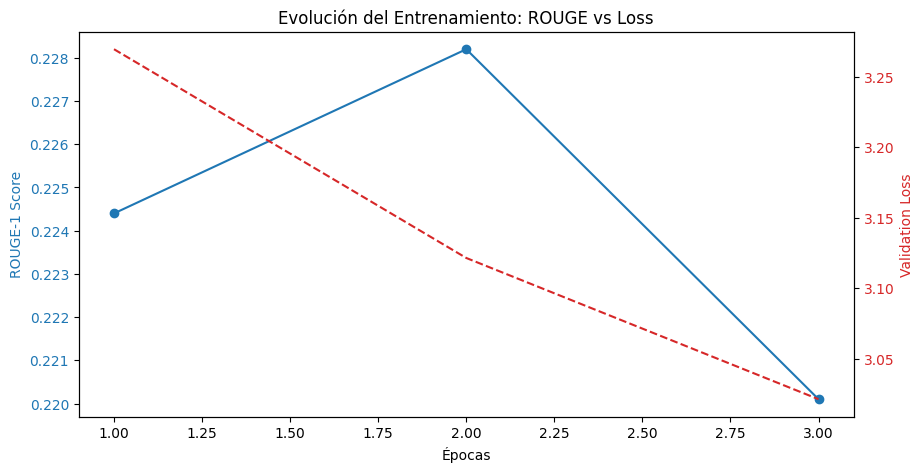

In [ ]:
# Extraer el historial de entrenamiento
history = trainer.state.log_history

# Filtrar las métricas de evaluación
eval_logs = [x for x in history if 'eval_rouge1' in x]

# Si has entrenado al menos una época completa, podrás graficar
if len(eval_logs) > 0:
    epochs = [x['epoch'] for x in eval_logs]
    rouge1 = [x['eval_rouge1'] for x in eval_logs]
    loss = [x['eval_loss'] for x in eval_logs]

    # Crear gráfica
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Eje izquierdo: ROUGE
    color = 'tab:blue'
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('ROUGE-1 Score', color=color)
    ax1.plot(epochs, rouge1, color=color, marker='o', label='Calidad Resumen (ROUGE)')
    ax1.tick_params(axis='y', labelcolor=color)

    # Eje derecho: LOSS
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Validation Loss', color=color)
    ax2.plot(epochs, loss, color=color, linestyle='--', label='Error (Loss)')
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Evolución del Entrenamiento: ROUGE vs Loss')
    plt.show()
else:
    print("No hay suficientes datos de evaluación para graficar")

En cuanto al **Validation Loss** (línea roja), observamos una tendencia claramente decreciente durante las tres épocas (bajando de aproximadamente 3.27 a 3.02). Esto confirma que el modelo sigue optimizando su función de coste matemática, reduciendo el error interno de forma constante.

Por otro lado, el **ROUGE-1 Score** (línea azul) muestra un comportamiento revelador. Experimenta un crecimiento positivo entre la época 1 y la 2, alcanzando su pico máximo de rendimiento (~0.228). Sin embargo, lo destacable es que durante la época 3 se produce una caída en la calidad del resumen, descendiendo hasta ~0.220.

Esta divergencia final (donde el Loss baja pero el ROUGE empeora) es un indicador clásico de sobreajuste (overfitting): el modelo ha empezado a memorizar los datos de entrenamiento en detrimento de la generalización. Por tanto, la gráfica nos indica que el punto óptimo del modelo se alcanzó en la Época 2.

Gracias a que la configuración de entrenamiento incluía el parámetro `load_best_model_at_end=True`, hemos podido recuperar y conservar automáticamente este checkpoint óptimo, descartando la versión sobreajustada final.

Una vez hemos observado la gráfica, vamos a realizar la inferencia y ver como el modelo hace los resumenes. Así que vamos a coger un ejemplo de test y vamos a realizar el resumen del artículo.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# 3. Bucle para generar los 3 primeros resúmenes
for idx in range(3):
    # Extraer texto y resumen real
    input_text = small_test_dataset[idx]["text"]
    target_text = small_test_dataset[idx]["summary"]

    # Tokenizar y mover a GPU
    input_ids = tokenizer("summarize: " + input_text, return_tensors="pt").input_ids.to(device)

    # Generar resumen
    outputs = model.generate(input_ids, max_length=128)
    generated_summary = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Mostrar resultados
    print(f"\n{'='*20} EJEMPLO {idx} {'='*20}")
    print("--- ARTÍCULO ORIGINAL (Inicio) ---")
    print(input_text)
    print("\n--- RESUMEN HUMANO (Real) ---")
    print(target_text)
    print("\n--- RESUMEN GENERADO MI TU MODELO ---")
    print(generated_summary)
    print("="*50)


==================== EJEMPLO 0 ====================
--- ARTÍCULO ORIGINAL (Inicio) ---
El Madrid había perdido en el Ramón Sánchez Pizjuán en sus últimas cuatro visitas. La alegría inundaba el vestuario del conjunto madridista después de romper esta mala racha gracias al gol de Benzema. “Ha sido un partido que se ha decidido por detalles. Sabíamos que para ganar aquí deberíamos tener una mentalidad muy fuerte. La clave es que nos hemos defendido como bloque, basculamos muy bien y metimos la que tuvimos”, afirmó Sergio Ramos. “Ahora vamos a tener una semana tranquila después de todo lo que se habla. Siempre tenemos hambre, nos vamos rodando, y poco un poco de calma porque esto es muy largo”, continuó el defensa del Madrid. Ramos se refirió al concepto de intensidad esgrimido por Zidane tras el duelo ante el PSG. “Son tres puntos muy importantes. Era pronto para dudar de este equipo”, dijo Ramos. “Todo lo que rodea al Madrid genera mucho. Hablar de entrenadores es faltarle al respeto al

1. **Puntos fuertes**:
- **Captura de la idea central**: el modelo demuestra una notable capacidad para identificar el núcleo de la noticia, incluso cuando el texto original es extenso. **Ejemplo 0**: Sintetiza correctamente que el entrenador (Zidane) elogia la "intensidad" del equipo, que es el tema recurrente en las declaraciones de Ramos y Zidane en el texto. **Ejemplo 1**: Identifica a los protagonistas clave ("Rosales", "Chimy Ávila" aunque con un pequeño error en el nombre) y el resultado ("0-1"), capturando la esencia de la victoria de Osasuna. **Ejemplo 2**: Reconoce que Higuaín es el protagonista de la acción ("El equipo de Higuaín") y que el partido tuvo una dinámica compleja ("juego ofensivo", "logra el empate"), aunque comete imprecisiones fácticas sobre el resultado final.

- **Estilo periodístico**: el modelo ha adoptado con éxito el tono y la jerga propios del periodismo deportivo español. Frases como "elogia la intensidad", "vuelve con buen pie a la máxima categoría" o "logra el empate" demuestran que el fine-tuning ha transferido el estilo del dataset MLSUM al modelo.

2. **Áreas de Mejora y Alucinaciones**:
- **Alucinaciones Fácticas**: tiende a inventar o mezclar datos en un intento de generar frases fluidas. **Ejemplo 1**: Dice "único estrella en la categoría", una frase que no está en el texto y es gramaticalmente dudosa. También inventa el nombre "Chiéllar" (mezcla de Chimy y Cuéllar). **Ejemplo 2**: Afirma que el equipo "logra el empate", cuando el texto original dice claramente que la Juventus ganó 1-2. Esto es un error crítico de comprensión lectora.
- **Repetición**: Persiste el problema de la repetición. **Ejemplo 0**: "...elogia la intensidad del equipo y elogia al equipo de Zidane y elogia el esfuerzo...". Esto confirma la necesidad de ajustar el parámetro `repetition_penalty` durante la inferencia.
- **Gramática Inconsistente**: En el **Ejemplo 1**, la frase "único estrella en la categoría" carece de concordancia gramatica (debería ser "única estrella").

3. **Comparación con el Resumen Humano**
- **Enfoque**: Los resúmenes humanos tienden a ser titulares informativos ("Un gol del argentino sirve para..."), mientras que el modelo intenta construir una narrativa más compleja, a veces tropezando en la ejecución.

- **Precisión**: El humano es 100% preciso en los hechos. El modelo, aunque semánticamente rico, sacrifica la precisión factual (resultado del partido, nombres) en favor de la fluidez del texto.

# Conclusiones

En este proyecto se ha implementado y evaluado el ajuste fino (*fine-tuning*) del modelo **mT5-small** para la tarea de resumen abstractivo de noticias en español, utilizando el dataset **MLSUM** filtrado por la categoría de deportes.

A partir de los resultados cuantitativos y cualitativos obtenidos, se extraen las siguientes conclusiones:
- **Arquitectura Seq2Seq**: se confirma que la arquitectura Encoder-Decoder del T5 es ideal para tareas de generación condicional. A diferencia de BERT (que clasifica) o Llama (que continua texto), T5 ha demostrado capacidad para procesar un contexto largo (la noticia) y reescribir una síntesis coherente, adoptando con éxito el "tono periodístico" deportivo del dataset.
- **Análisis del entrenamiento y sobreajuste**: el entrenamiento evidencia un punto de inflexión claro. Mientras que la función de pérdida (Validation Loss) decreció constantemente hasta 3.02, la métrica de calidad ROUGE-1 alcanzó su pico en la Época 2 (0.2282) y empeoró en la Época 3 (0.2201). Esto indica un inicio de sobreajuste en la última época del entrenamiento. La configuración de `load_best_model_at_end=True` es crucial para descartar la versión sobreajustada y conservar el checkpoint óptimo de la segunda época

Aunque las métricas ROUGE son aceptables para un modelo "small" con solo 1.000 ejemplos, el análisis manual revela una **limitación importante**:
- **Alucinaciones**: el modelo tiende a inventar detalles (como resultados de partidos erróneos o nombres de jugadores mezclados) en favor de mantener la fluidez gramatical. Esto es un riesgo inherente a los modelos generativos abstractivos frente a los extractivos.

En cuanto a los **trabajos futuros**, Para mejorar la fiabilidad del sistema en un entorno productivo, se propone:
- Aumentar el volumen de datos de entrenamiento (de 1.000 a 10.000 ejemplos) para mejorar la generalización.
- Implementar *Beam Search* durante la inferencia para mejorar la calidad de las oraciones generadas.
- Incorporar el parámetro `repetition_penalty` durante la inferencia para penalizar la generación de tokens ya utilizados, reduciendo así la redundancia en los resúmenes.